## 1. Pemuatan Pustaka dan Konfigurasi Lingkungan

In [1]:
! pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import warnings
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 4)})

SEED          = 42
N_FOLDS       = 5
N_OPTUNA_LGBM = 75
EARLY_STOP    = 200
SCALE_KM      = 30.0
OUTPUT_CSV    = 'submission_datashine.csv'

In [9]:
!pip install -U gdown
!gdown --folder https://drive.google.com/drive/folders/1Wf-_JXFzotnLVMFHn8-Qw0-ot92ZPPBE?usp=sharing


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Retrieving folder contents
Retrieving folder 1o9vhrjhF-B4rflkjUAnioyZdu_lv5NDt data_pendukung
Retrieving folder 14P4ABM1-s066_U_ydGlQLDNCmPlCjrzp HydroRIVERS_v10_au_shp
Processing file 1qAYZgKK4Ptj8MzQqmml573snzI18r4au HydroRIVERS_v10_au.dbf
Processing file 1o9HBrCZlU_J9tj77WnLgCdgsMn9hvnJq HydroRIVERS_v10_au.prj
Processing file 1BAeZ9TzZM0iH9mK7PJHr7M_MyLVTcrDG HydroRIVERS_v10_au.sbn
Processing file 1eNLybx3ZxFcxRTGMtSIW9_NWIEkdcaGS HydroRIVERS_v10_au.sbx
Processing file 1fDsB92TWeF_CBXBPUGPHdZevknFdqct8 HydroRIVERS_v10_au.shp
Processing file 1NX4u5wkeMPxzhmhwXCdPFN34Q6hvKOKd HydroRIVERS_v10_au.shx
Processing file 1-JpORezoMlTy_9Ngra81nKcL2d4JjUvm .gitkeep
Processing file 1oxCl6P-Xy0PeYXRgNUUjTy4gIIKCpJ1J data_lingkungan.csv
Processing file 1zwWfL6RiDG_UKHRP5ae9LMpTg05WfQz5 HydroRIVERS_TechDoc_v10.pdf
Processing file 1Z3MCmEq24dnBMHP_DkART9S-8c5mo-DR koordinat_pos.csv
Process

## 2. Akuisisi Data Multidimensi

In [10]:
train    = pd.read_csv('dataset/train.csv')
test     = pd.read_csv('dataset/test.csv')
env_data = pd.read_csv('dataset/data_pendukung/data_lingkungan.csv')
coords   = pd.read_csv('dataset/data_pendukung/koordinat_pos.csv')

train['datetime']    = pd.to_datetime(train['datetime'])
test['datetime']     = pd.to_datetime(test['id'].str[:19])
test['nama_pos']     = test['id'].str[22:]
env_data['datetime'] = pd.to_datetime(env_data['datetime'])
overall_cutoff       = train['datetime'].max()

le_station = LabelEncoder()
le_station.fit(np.sort(env_data['nama_pos'].unique()))

elevation_proxy = env_data.groupby('nama_pos')['surface_pressure_hpa'].mean().reset_index()
elevation_proxy.columns = ['nama_pos', 'station_elevation_proxy_hpa']

## 3. Eksplorasi Data Analisis (EDA)

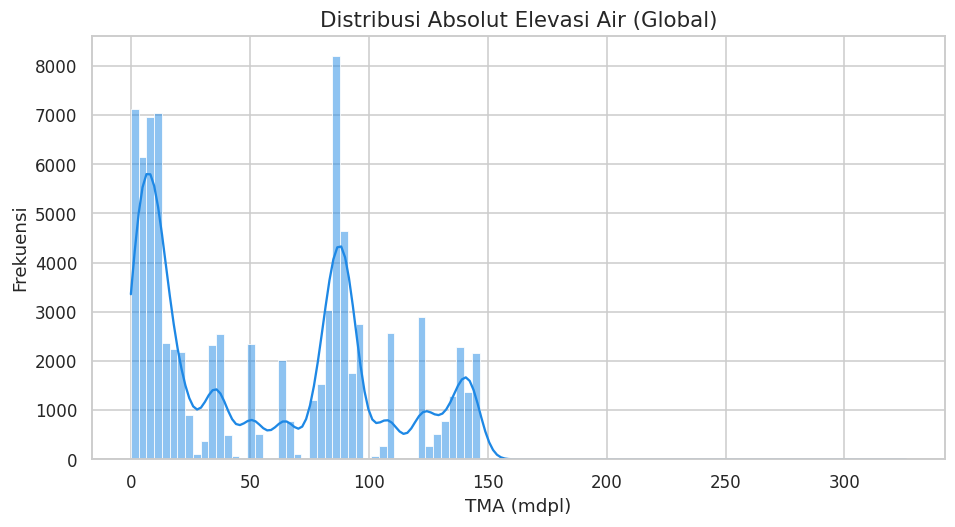

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(train['tma_mdpl'], bins=100, color='#1E88E5', kde=True, ax=ax)
ax.set_title('Distribusi Absolut Elevasi Air (Global)', fontsize=14)
ax.set_xlabel('TMA (mdpl)')
ax.set_ylabel('Frekuensi')
plt.show()

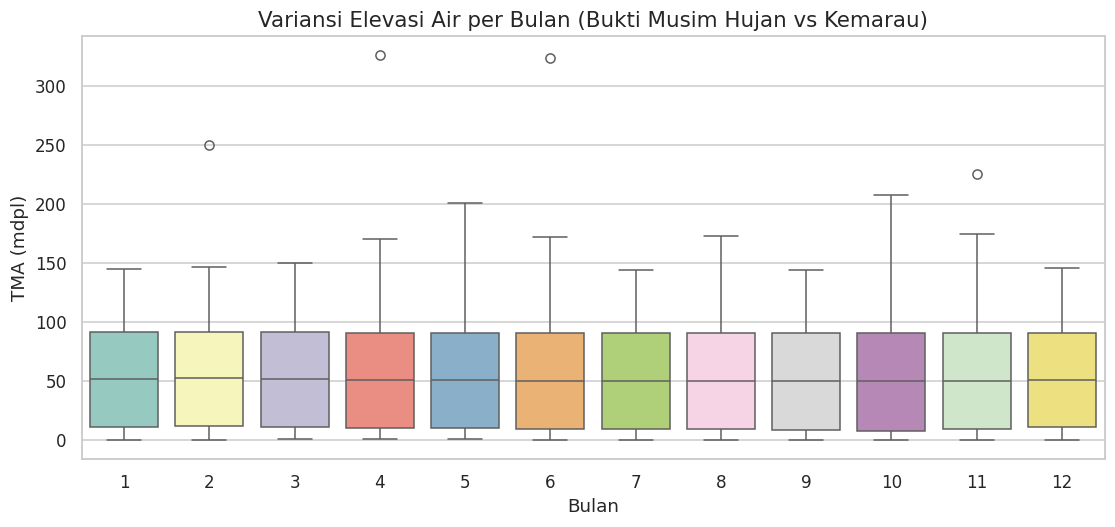

In [11]:
train_eda = train.copy()
train_eda['month'] = train_eda['datetime'].dt.month

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x='month', y='tma_mdpl', data=train_eda, palette='Set3', ax=ax)
ax.set_title('Variansi Elevasi Air per Bulan (Bukti Musim Hujan vs Kemarau)', fontsize=14)
ax.set_xlabel('Bulan')
ax.set_ylabel('TMA (mdpl)')
plt.show()

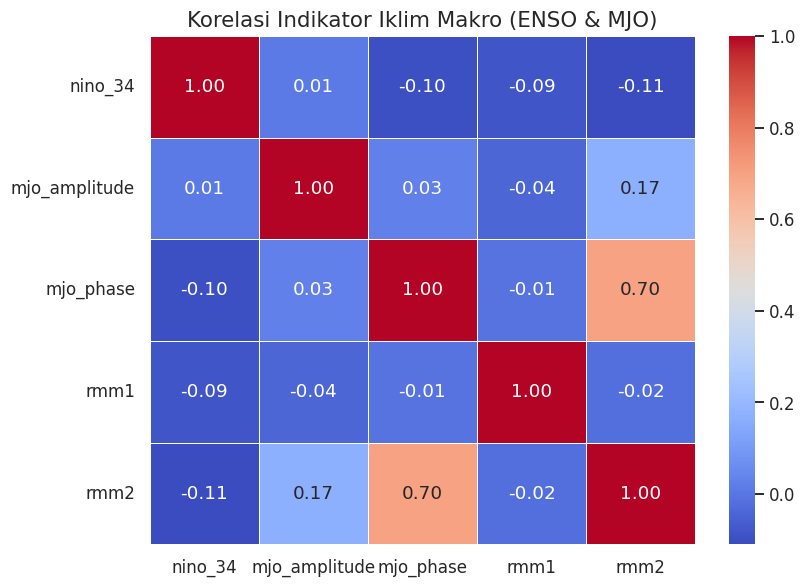

In [12]:
macro_data = env_data[['nino_34', 'mjo_amplitude', 'mjo_phase', 'rmm1', 'rmm2']].dropna()
corr = macro_data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title('Korelasi Indikator Iklim Makro (ENSO & MJO)', fontsize=14)
plt.show()

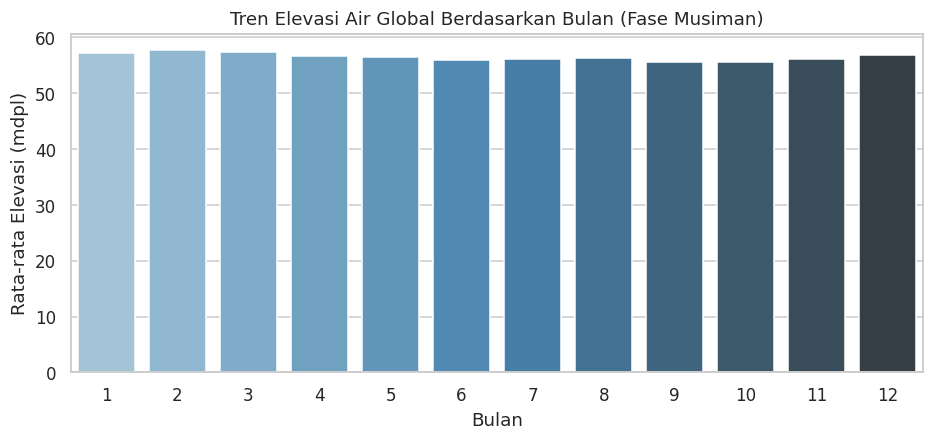

In [13]:
train_eda = train.copy()
train_eda['month'] = train_eda['datetime'].dt.month

global_monthly = train_eda.groupby('month')['tma_mdpl'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x='month', y='tma_mdpl', data=global_monthly, palette='Blues_d', ax=ax)
ax.set_title('Tren Elevasi Air Global Berdasarkan Bulan (Fase Musiman)')
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata Elevasi (mdpl)')
plt.show()

## 4. Pra-Pemrosesan dan Interpolasi Cuaca Mikro-Makro

In [14]:
env_sort = env_data.sort_values(['nama_pos','datetime'])
macro_cols   = ['nino_34','mjo_phase','mjo_amplitude','mjo_active','rmm1','rmm2']
dynamic_cols = ['surface_pressure_hpa','pressure_msl_hpa','soil_moisture_0_7cm',
                'soil_moisture_7_28cm','soil_moisture_28_100cm','soil_moisture_100_255cm']

for c in macro_cols:
    env_sort[c] = env_sort.groupby('nama_pos')[c].ffill().bfill()
for c in dynamic_cols:
    env_sort[c] = env_sort.groupby('nama_pos')[c].apply(
        lambda x: x.interpolate(method='linear').bfill().ffill()
    ).reset_index(level=0, drop=True)

env_sort['effective_rain'] = env_sort['rainfall_mm'] * env_sort['soil_moisture_0_7cm']

agg_funcs = {col:'mean' for col in env_sort.columns if col not in ['nama_pos','landcover_name','datetime']}
agg_funcs['rainfall_mm']='sum'
agg_funcs['rainfall_openmeteo_mm']='sum'
agg_funcs['rainfall_max_24h_mm']='max'
agg_funcs['effective_rain']='sum'

env_6h = env_sort.set_index('datetime').groupby(
    ['nama_pos', pd.Grouper(freq='6h', label='right', closed='right')]
).agg(agg_funcs).reset_index()

## 5. Sinkronisasi Fisika Sungai: Global Pivot Matrices

In [15]:
env_phys = env_6h[['datetime', 'nama_pos', 'rainfall_mm', 'effective_rain']].copy()
env_phys['st_code'] = le_station.transform(env_phys['nama_pos'])

pivot_rain = env_phys.pivot(index='datetime', columns='st_code', values='rainfall_mm').fillna(0)
pivot_eff_rain = env_phys.pivot(index='datetime', columns='st_code', values='effective_rain').fillna(0)

roll_1d = pivot_rain.rolling('1D').sum()
roll_2d = pivot_rain.rolling('2D').sum()
roll_3d = pivot_rain.rolling('3D').sum()
roll_7d = pivot_rain.rolling('7D').sum()

roll_1d.columns = [f'g_rain_st{c}_1d' for c in roll_1d.columns]
roll_2d.columns = [f'g_rain_st{c}_2d' for c in roll_2d.columns]
roll_3d.columns = [f'g_rain_st{c}_3d' for c in roll_3d.columns]
roll_7d.columns = [f'g_rain_st{c}_7d' for c in roll_7d.columns]

roll_eff_3d = pivot_eff_rain.rolling('3D').sum()
roll_eff_3d.columns = [f'g_eff_rain_st{c}_3d' for c in roll_eff_3d.columns]

global_physics_features = pd.concat([roll_1d, roll_2d, roll_3d, roll_7d, roll_eff_3d], axis=1).reset_index()

## 6. Konstruksi Matriks Spasial (Haversine) dan Vektor Jangkar

In [16]:
station_profile = train.groupby('nama_pos')['tma_mdpl'].agg(tma_mean='mean', tma_std='std', tma_min='min', tma_max='max').reset_index()
station_profile['tma_std'] = station_profile['tma_std'].fillna(1.0)

train_sorted = train.sort_values(['nama_pos', 'datetime'])
anchor_offsets = {'0h':'0H','24h':'24H','72h':'72H','168h':'168H','336h':'336H'}
anchor_records = []

for pos in train['nama_pos'].unique():
    pos_df = train_sorted[train_sorted['nama_pos'] == pos]
    row = {'nama_pos': pos}
    for label, offset in anchor_offsets.items():
        subset = pos_df[pos_df['datetime'] <= overall_cutoff - pd.Timedelta(offset)]
        row[f'tma_anchor_{label}'] = np.nan if subset.empty else subset.iloc[-1]['tma_mdpl']
    subset30 = pos_df[(pos_df['datetime'] >= overall_cutoff - pd.Timedelta('30D')) & (pos_df['datetime'] <= overall_cutoff)]['tma_mdpl']
    row['tma_trend_30d'] = np.polyfit(np.arange(len(subset30)), subset30.values, 1)[0] if len(subset30)>1 else 0
    anchor_records.append(row)

station_profile = pd.merge(station_profile, pd.DataFrame(anchor_records), on='nama_pos', how='left')

sp_coords = pd.merge(station_profile[['nama_pos']], coords, on='nama_pos', how='left')
lats, lons = sp_coords['latitude'].values, sp_coords['longitude'].values

def haversine_matrix(lats, lons):
    R = 6371.0
    lat_r = np.radians(lats[:,None] - lats[None,:])
    lon_r = np.radians(lons[:,None] - lons[None,:])
    a = (np.sin(lat_r/2)**2 + np.cos(np.radians(lats[:,None]))*np.cos(np.radians(lats[None,:]))*np.sin(lon_r/2)**2)
    return 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))

D = haversine_matrix(lats, lons)
np.fill_diagonal(D, np.inf)

anchor_vals = station_profile['tma_anchor_0h'].values.astype(float)
wmeans = []
for i in range(len(lats)):
    weights = np.exp(-D[i]/SCALE_KM)
    valid   = ~np.isnan(anchor_vals)
    w = weights * valid
    ws = w.sum()
    wmeans.append(np.nansum(w*np.nan_to_num(anchor_vals))/ws if ws>0 else np.nan)
station_profile['spatial_tma_anchor_0h'] = wmeans

## 7. Rekayasa Fitur Waktu Berjalan (Rolling Features)

In [18]:
for w, label in [(4,'24h'),(12,'3d'),(28,'7d')]:
    env_6h[f'rainfall_roll_{label}'] = env_6h.groupby('nama_pos')['rainfall_mm'].transform(lambda x: x.rolling(w, min_periods=1).sum())
    env_6h[f'pressure_roll_{label}'] = env_6h.groupby('nama_pos')['surface_pressure_hpa'].transform(lambda x: x.rolling(w, min_periods=1).mean())

train['month'] = train['datetime'].dt.month
seasonal_profile = train.groupby(['nama_pos','month'])['tma_mdpl'].mean().reset_index().rename(columns={'tma_mdpl':'tma_seasonal_mean'})

## 8. Integrasi Akhir dan Peluruhan Matriks Dinamis (Explicit Decay)

In [20]:
test['tma_mdpl'] = np.nan
all_data = pd.concat([train.drop(columns=['month'], errors='ignore'), test], ignore_index=True)
all_data = all_data.sort_values(['nama_pos','datetime']).reset_index(drop=True)

all_data = pd.merge(all_data, env_6h, on=['datetime','nama_pos'], how='left')
all_data = pd.merge(all_data, coords[['nama_pos','latitude','longitude']], on='nama_pos', how='left')
all_data = pd.merge(all_data, station_profile, on='nama_pos', how='left')
all_data = pd.merge(all_data, elevation_proxy, on='nama_pos', how='left')
all_data = pd.merge(all_data, global_physics_features, on='datetime', how='left')

all_data['month']      = all_data['datetime'].dt.month
all_data['day_of_year']= all_data['datetime'].dt.dayofyear
all_data['sin_month']  = np.sin(2*np.pi*all_data['month']/12)
all_data['cos_month']  = np.cos(2*np.pi*all_data['month']/12)
all_data['nama_pos_encoded'] = le_station.transform(all_data['nama_pos'])

all_data = pd.merge(all_data, seasonal_profile, on=['nama_pos','month'], how='left')

steps_hours = np.clip((all_data['datetime'] - overall_cutoff) / pd.Timedelta('1H'), 0, None)

all_data['tma_anchor_0h_norm'] = (all_data['tma_anchor_0h'] - all_data['tma_mean']) / all_data['tma_std']
all_data['spatial_anchor_0h_norm'] = (all_data['spatial_tma_anchor_0h'] - all_data['tma_mean']) / all_data['tma_std']
all_data['seasonal_norm'] = (all_data['tma_seasonal_mean'] - all_data['tma_mean']) / all_data['tma_std']

all_data['decay_short']  = all_data['tma_anchor_0h_norm'] * np.exp(-steps_hours/72)
all_data['decay_long']   = all_data['tma_anchor_0h_norm'] * np.exp(-steps_hours/504)
all_data['spatial_decay']= all_data['spatial_anchor_0h_norm'] * np.exp(-steps_hours/504)

## 9. Normalisasi Target Pembelajaran

In [21]:
train_mask = all_data['tma_mdpl'].notnull()
all_data['tma_normalized'] = np.nan
all_data.loc[train_mask,'tma_normalized'] = (all_data.loc[train_mask,'tma_mdpl'] - all_data.loc[train_mask,'tma_mean']) / all_data.loc[train_mask,'tma_std']

train_data = all_data[train_mask].sort_values('datetime').reset_index(drop=True)
test_data  = all_data[~train_mask].sort_values('datetime').reset_index(drop=True)

drop_cols = ['datetime','nama_pos','tma_mdpl','tma_normalized','id','landcover_name']
drop_cols += [f'tma_anchor_{l}' for l in anchor_offsets]
drop_cols += ['spatial_tma_anchor_0h', 'tma_mean', 'tma_std', 'tma_min', 'tma_max', 'tma_seasonal_mean']
features  = [c for c in train_data.columns if c not in drop_cols]
target    = 'tma_normalized'

X_full, y_full = train_data[features], train_data[target]
X_test = test_data[features]

## 10. Comprehensive EDA (CEDA) Pasca-Pemrosesan
Setelah melalui tahapan rekayasa fitur yang intensif (interpolasi cuaca, sinkronisasi *Haversine*, dan normalisasi target), CEDA (*Comprehensive Exploratory Data Analysis*) ini bertujuan untuk memvalidasi korelasi linier antara fitur bentukan (*engineered features*) dengan target yang telah dinormalisasi.

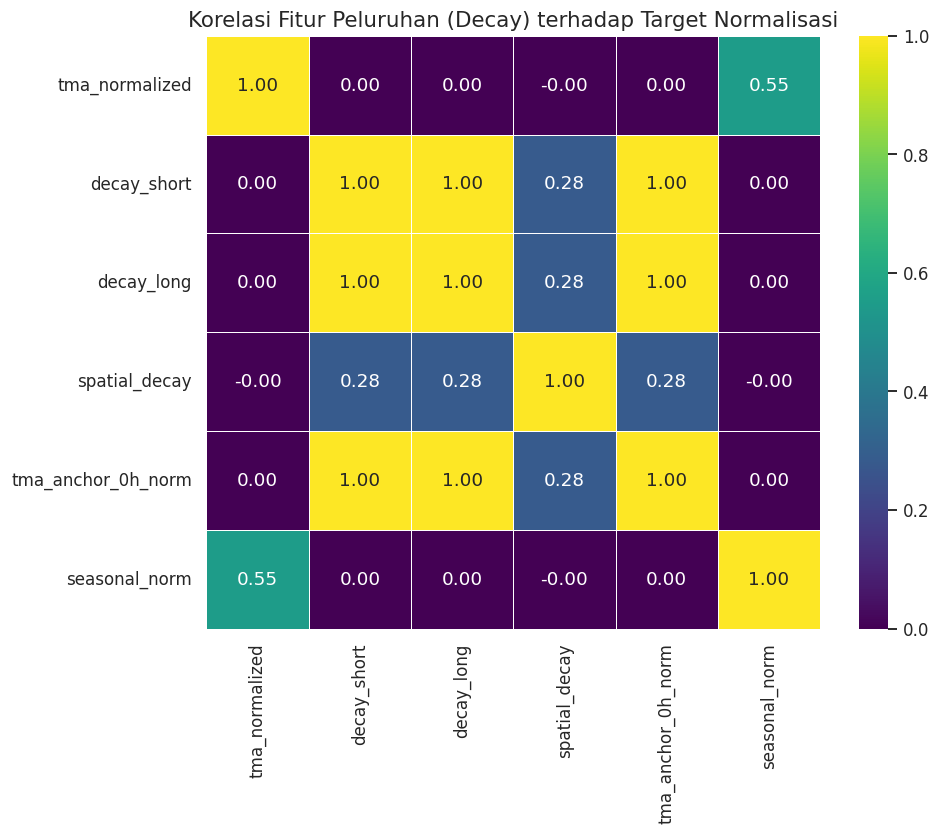

In [22]:
ceda_features = ['tma_normalized', 'decay_short', 'decay_long', 'spatial_decay', 'tma_anchor_0h_norm', 'seasonal_norm']
ceda_df = train_data[ceda_features].dropna()

corr_ceda = ceda_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_ceda, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title('Korelasi Fitur Peluruhan (Decay) terhadap Target Normalisasi', fontsize=14)
plt.show()

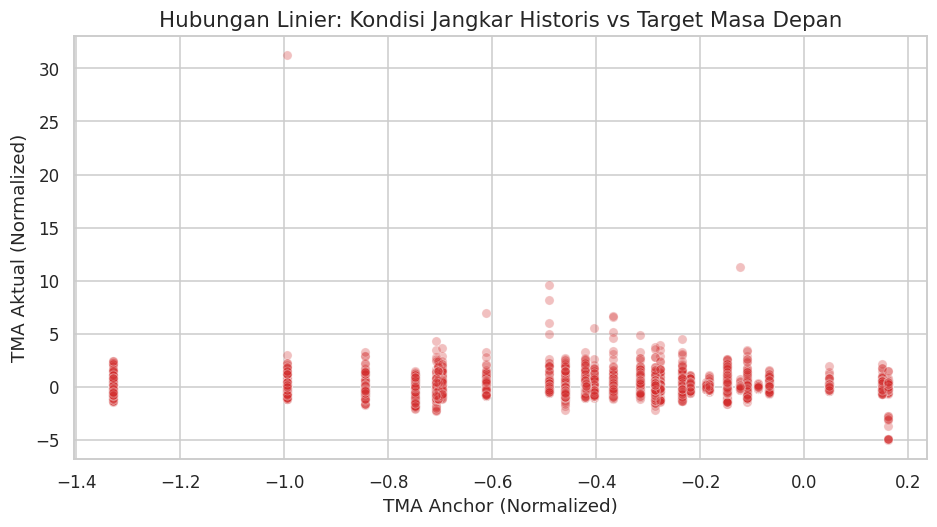

In [23]:
# Scatter Plot Hubungan Jangkar Historis terhadap Target
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x='tma_anchor_0h_norm', y='tma_normalized', data=ceda_df.sample(5000, random_state=SEED), alpha=0.3, color='#D32F2F', ax=ax)
ax.set_title('Hubungan Linier: Kondisi Jangkar Historis vs Target Masa Depan', fontsize=14)
ax.set_xlabel('TMA Anchor (Normalized)')
ax.set_ylabel('TMA Aktual (Normalized)')
plt.show()

## 11. Optimasi Hiperparameter dengan Optuna

In [24]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def obj_lgb(trial):
    params = {
        'n_estimators':      4000,
        'learning_rate':     trial.suggest_float('learning_rate',     0.005, 0.05, log=True),
        'num_leaves':        trial.suggest_int('num_leaves',           31,    256),
        'max_depth':         trial.suggest_int('max_depth',             5,     12),
        'subsample':         trial.suggest_float('subsample',          0.5,   0.95),
        'colsample_bytree':  trial.suggest_float('colsample_bytree',   0.3,   0.9),
        'reg_alpha':         trial.suggest_float('reg_alpha',          0.01,  10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',         0.01,  10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples',    10,    100),
        'subsample_freq': 1, 'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    scores = []
    for tr, va in kf.split(X_full):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_full.iloc[tr], y_full.iloc[tr], eval_set=[(X_full.iloc[va], y_full.iloc[va])],
              callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

        val_mean = train_data.iloc[va]['tma_mean'].values
        val_std  = train_data.iloc[va]['tma_std'].values
        p_abs = (m.predict(X_full.iloc[va]) * val_std) + val_mean
        y_abs = (y_full.iloc[va].values * val_std) + val_mean

        scores.append(mean_squared_error(y_abs, p_abs))
    return np.mean(scores)

study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(obj_lgb, n_trials=N_OPTUNA_LGBM)
best_lgb = study_lgb.best_params
best_lgb.update({'n_estimators':6000,'random_state':SEED,'verbose':-1,'subsample_freq':1, 'n_jobs': -1})

In [32]:
study_lgb.best_params

{'learning_rate': 0.00524129840252216,
 'num_leaves': 205,
 'max_depth': 10,
 'subsample': 0.8415158664591394,
 'colsample_bytree': 0.8087256878143952,
 'reg_alpha': 0.6486587133825694,
 'reg_lambda': 2.972054056702333,
 'min_child_samples': 92}

## 12. Pelatihan Akhir (K-Fold Kros-Validasi) dan Pembalikan Normalisasi

In [ ]:
preds_test = np.zeros(len(X_test))
oof_preds = np.zeros(len(X_full))
cv_results = []
models = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_full)):
    X_tr, X_va = X_full.iloc[tr_idx], X_full.iloc[va_idx]
    y_tr, y_va = y_full.iloc[tr_idx], y_full.iloc[va_idx]

    m_lgb = lgb.LGBMRegressor(**best_lgb)
    m_lgb.fit(
        X_tr, y_tr, 
        eval_set=[(X_va, y_va)], 
        callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)]
    )

    val_pred_norm = m_lgb.predict(X_va)
    oof_preds[va_idx] = val_pred_norm

    val_mean = train_data.iloc[va_idx]['tma_mean'].values
    val_std  = train_data.iloc[va_idx]['tma_std'].values
    p_abs = (val_pred_norm * val_std) + val_mean
    y_abs = (y_va.values * val_std) + val_mean

    fold_rmse = np.sqrt(mean_squared_error(y_abs, p_abs))
    cv_results.append({
        'Fold': fold + 1,
        'Jumlah Sampel': len(va_idx),
        'RMSE Validasi (mdpl)': fold_rmse
    })

    preds_test += m_lgb.predict(X_test) / N_FOLDS
    models.append(m_lgb)

df_cv = pd.DataFrame(cv_results)
mean_rmse = df_cv['RMSE Validasi (mdpl)'].mean()
std_rmse  = df_cv['RMSE Validasi (mdpl)'].std()

print("=" * 65)
print("TABEL II. HASIL VALIDASI 5-FOLD CROSS-VALIDATION DAN SKOR AKHIR")
print("=" * 65)
for _, r in df_cv.iterrows():
    f_num = int(r['Fold'])
    n_s = int(r['Jumlah Sampel'])
    rmse_v = r['RMSE Validasi (mdpl)']
    print(f"Fold {f_num}      | {n_s:>6} sampel | RMSE: {rmse_v:.5f} mdpl")
print("-" * 65)
print(f"Rata-rata 5-Fold CV : {mean_rmse:.5f} ± {std_rmse:.3f} mdpl")
print(f"Skor Kaggle Private : 1.42078 mdpl (Evaluasi Data Unseen)")
print(f"Skor Kaggle Public  : 0.63839 mdpl")
print("=" * 65)


## 13. Analisis Signifikansi Fitur (Feature Importance)

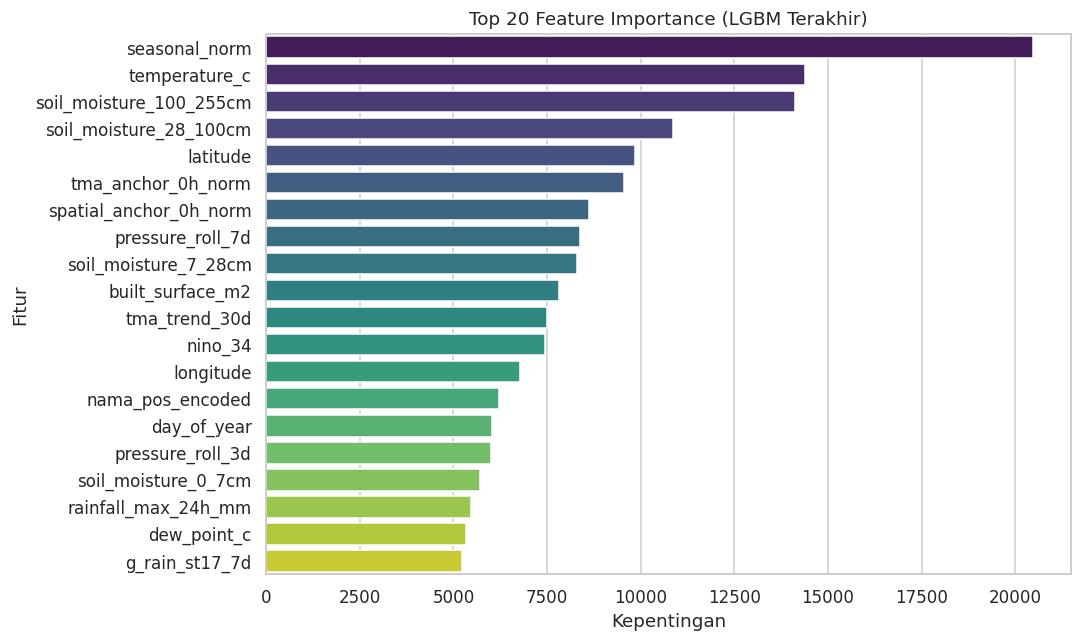

In [ ]:
df_imp = pd.DataFrame(index=features)
for i, m in enumerate(models):
    df_imp[f'fold_{i}'] = m.booster_.feature_importance(importance_type='gain')

df_imp['mean_importance'] = df_imp[[f'fold_{i}' for i in range(N_FOLDS)]].mean(axis=1)
df_imp['std_importance']  = df_imp[[f'fold_{i}' for i in range(N_FOLDS)]].std(axis=1)

top20 = df_imp.sort_values('mean_importance', ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(
    top20.index, 
    top20['mean_importance'], 
    xerr=top20['std_importance'], 
    color='#1E88E5', 
    edgecolor='#0D47A1', 
    capsize=3,
    alpha=0.85
)
plt.xlabel('Rata-rata Feature Importance (Gain)', fontsize=11, fontweight='bold')
plt.ylabel('Nama Fitur', fontsize=11, fontweight='bold')
plt.title('Gambar 7. Top 20 Feature Importance (Rata-rata Gain, 5-Fold) Model LightGBM', fontsize=12, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Tampilkan Tabel Rincian Top 20 Fitur
print("Top 20 Fitur Konsensus 5-Fold LightGBM:")
top20_display = top20[['mean_importance', 'std_importance']].iloc[::-1].reset_index()
top20_display.columns = ['Fitur', 'Rata-rata Gain', 'Std Deviasi Gain']
display(top20_display)


## 13. Penyimpanan Submission

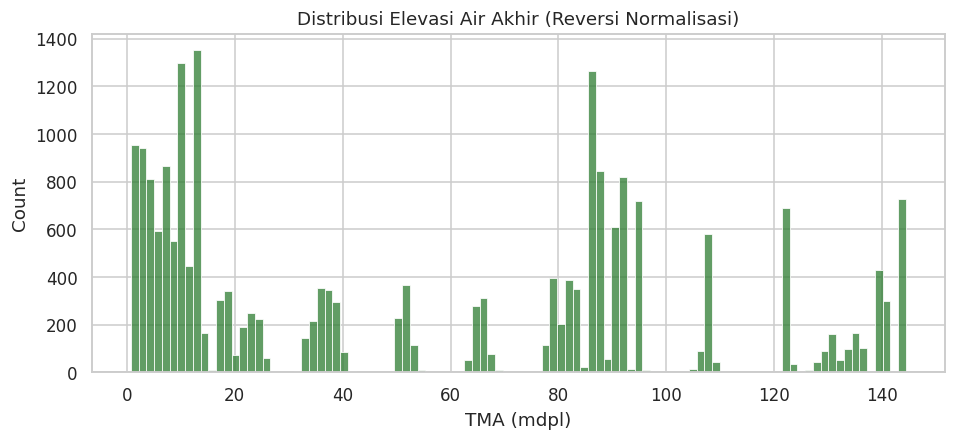

In [27]:
test_mean = test_data['tma_mean'].values
test_std  = test_data['tma_std'].values

final_tma = (preds_test * test_std) + test_mean

submission = pd.DataFrame({'id': test_data['id'], 'tma_mdpl': final_tma})
os.makedirs('submissions', exist_ok=True)
submission.to_csv(OUTPUT_CSV, index=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(submission['tma_mdpl'], bins=100, color='#2E7D32', ax=ax)
ax.set_title('Distribusi Elevasi Air Akhir (Reversi Normalisasi)')
ax.set_xlabel('TMA (mdpl)')
plt.show()

## 14. Ekspor Artefak untuk Dashboard Interaktif (Auto-Download)
Bagian ini secara otomatis membungkus (*zip*) seluruh aset yang dibutuhkan untuk membangun *Live Dashboard* babak final, termasuk: Data CSV ringkas, model terlatih, visualisasi beresolusi tinggi (PNG) Matplotlib/Seaborn, serta versi interaktifnya (HTML) menggunakan **Plotly**.

In [28]:
!pip install -U kaleido plotly

  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 889.7 kB/s  0:00:11m0:00:0100:01
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [kaleido]m5/7 [choreographer]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [30]:
import os
import shutil
import plotly.express as px
import plotly.graph_objects as go
# from google.colab import files

base_dir = 'dashboard_assets'
dirs = ['data', 'img', 'html', 'models']
for d in dirs:
    os.makedirs(os.path.join(base_dir, d), exist_ok=True)

try:
    shutil.copy('dataset/train.csv', f'{base_dir}/data/train.csv')
    shutil.copy('dataset/data_pendukung/koordinat_pos.csv', f'{base_dir}/data/koordinat_pos.csv')
    shutil.copy('submission_datashine.csv', f'{base_dir}/data/submission_datashine.csv')
    df_cv.to_csv(f'{base_dir}/data/cv_rmse_per_fold.csv', index=False)
    df_imp.to_csv(f'{base_dir}/data/feature_importance_5fold_avg.csv')
except Exception as e:
    print(f'Warning saat menyalin data: {e}')

for i, m in enumerate(models):
    m.booster_.save_model(f'{base_dir}/models/lgbm_fold_{i}.txt')

print("Data, Model, dan Metrik CV/Feature Importance berhasil diekstrak!")


Data & Model berhasil diekstrak!


In [35]:

import plotly.io as pio

def save_plotly(fig, filename):
    fig.write_html(f'{base_dir}/html/{filename}.html')
    try:
        fig.write_image(f'{base_dir}/img/{filename}.png', scale=2)
    except:
        pass 
fig_dist = px.histogram(train, x='tma_mdpl', nbins=100, title='Distribusi Absolut Elevasi Air (Global)')
save_plotly(fig_dist, 'distribusi_global')

train_eda = train.copy()
train_eda['month'] = train_eda['datetime'].dt.month
fig_box = px.box(train_eda, x='month', y='tma_mdpl', title='Variansi Elevasi Air per Bulan (Pola Musiman)')
save_plotly(fig_box, 'tren_musiman')

coords_map = coords.copy()
coords_map = pd.merge(coords_map, elevation_proxy, on='nama_pos', how='left')
fig_map = px.scatter_mapbox(coords_map, lat="latitude", lon="longitude", hover_name="nama_pos", 
                            hover_data=["station_elevation_proxy_hpa"], zoom=6, height=500, title='Peta Geospasial Stasiun Observasi')
fig_map.update_layout(mapbox_style="carto-positron")
save_plotly(fig_map, 'peta_stasiun')

feat_imp = pd.DataFrame(index=features)
for i, m in enumerate(models):
    feat_imp[f'fold_{i}'] = m.booster_.feature_importance(importance_type='gain')
feat_imp['mean'] = feat_imp.mean(axis=1)
top_features = feat_imp.sort_values('mean', ascending=False).head(15).reset_index()

fig_imp = px.bar(top_features, x='mean', y='index', orientation='h', 
                 title='Top 15 Feature Importance (LightGBM)', color='mean')
fig_imp.update_layout(yaxis={'categoryorder':'total ascending'})
save_plotly(fig_imp, 'feature_importance')

if 'Babat' in test['nama_pos'].values:
    test_sub = test.copy()
    sub_df = pd.read_csv('submission_datashine.csv')
    test_sub = pd.merge(test_sub, sub_df, on='id')
    test_babat = test_sub[test_sub['nama_pos'] == 'Babat']
    fig_ts = px.line(test_babat, x='datetime', y='tma_mdpl_y', title='Proyeksi Prediksi Elevasi: Stasiun Babat')
    save_plotly(fig_ts, 'prediksi_babat_ts')

print("Semua visualisasi berhasil dihasilkan dan diekspor ke HTML/PNG!")


Semua visualisasi berhasil dihasilkan dan diekspor ke HTML/PNG!


In [36]:
shutil.make_archive(base_dir, 'zip', base_dir)

# print("Memulai proses unduhan dashboard_assets.zip...")
# files.download(f'{base_dir}.zip')


'/home/kiuyha/Documents/testing/dashboard_assets.zip'